# Contextual Bandits & Switch-DR

Notebooks 01-04 fit a recommender offline and then asked "how good would a
*fixed* candidate policy have been?" using off-policy evaluation on logged
data. This notebook asks the online question instead: how does a recommender
*learn* a good policy while interacting with users directly, and how much
does exploration cost along the way?

Two contextual bandits, both implemented from scratch in `src/ope/bandits.py`:

- **LinUCB** (Li et al., 2010) — deterministic, explores via an upper
  confidence bound on the predicted reward.
- **Linear Thompson Sampling** (Agrawal & Goyal, 2013) — stochastic, samples
  from a Bayesian posterior over each arm's reward model every round.

Both maintain one ridge-regression head per candidate item and use the
context = the user's latent factor vector — the same linear structure the
iALS recommender itself is built on, just learned online instead of by batch
ALS.

We then close the loop back to OPE: take the bandit's *learned* policy after
the simulation, and evaluate it against ground truth with **Switch-DR**
(`src/ope/estimators.py`), the estimator added in this session that trades a
little bias for much lower variance by capping the IPS correction's
importance weight.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

## 1. Setup: candidate items and ground-truth reward

Same construction as notebook 04 — the top-200 most popular items form the
candidate action set, and ground truth is whether the user actually liked
the item (only knowable here because this is a controlled simulation built
from real MovieLens interactions).

The bandit's context is a *compact* (8-factor) iALS user embedding rather
than the 64-factor one used for the offline recommender: with only ~20,000
online rounds spread across 200 arms, a lower-dimensional ridge regression
per arm is far more sample-efficient to learn online — a real trade-off
between representational power and online learning speed.

In [2]:
from src.data.load import load_ratings, temporal_split
from src.recommenders.ials import IALS

df = load_ratings(); sp = temporal_split(df, 0.2, 10)
train = sp.train_matrix()

pop = np.asarray(train.sum(axis=0)).ravel()
users = np.arange(sp.n_users)
N_CAND = 200
cand = np.argsort(-pop)[:N_CAND]

liked = set(map(tuple, df[df.liked == 1][["user_idx", "item_idx"]].values))
R = np.array([[1.0 if (u, i) in liked else 0.0 for i in cand] for u in users])
print(f"reward matrix: {R.shape}, base like-rate {R.mean():.3f}")

CONTEXT_FACTORS = 8
ials_ctx = IALS(factors=CONTEXT_FACTORS, iterations=15).fit(train)
user_context = ials_ctx.user_factors_
print(f"context features: {user_context.shape}")

reward matrix: (6040, 200), base like-rate 0.180


context features: (6040, 8)


## 2. Online simulation: LinUCB vs Thompson Sampling vs Random

Each round draws a random user, lets the policy pick one of the 200
candidate items, reveals whether that user actually liked it, and lets the
policy update. Regret is the gap to the best arm available for that user
that round.

In [3]:
from src.ope.bandits import LinUCB, LinearThompsonSampling, RandomPolicy, run_bandit_simulation

N_ROUNDS = 20_000

linucb = LinUCB(n_arms=N_CAND, dim=CONTEXT_FACTORS, alpha=1.0)
thompson = LinearThompsonSampling(n_arms=N_CAND, dim=CONTEXT_FACTORS, v=0.5, seed=0)
random_policy = RandomPolicy(n_arms=N_CAND, seed=0)

results = {
    "LinUCB": run_bandit_simulation(linucb, user_context, R, N_ROUNDS, seed=0),
    "Thompson Sampling": run_bandit_simulation(thompson, user_context, R, N_ROUNDS, seed=0),
    "Random": run_bandit_simulation(random_policy, user_context, R, N_ROUNDS, seed=0),
}

tail = int(N_ROUNDS * 0.2)
summary = pd.DataFrame({
    name: {
        "avg_regret_overall": res["regret"].mean(),
        "avg_regret_first_20pct": res["regret"][:tail].mean(),
        "avg_regret_last_20pct": res["regret"][-tail:].mean(),
        "cumulative_regret": res["cumulative_regret"][-1],
    }
    for name, res in results.items()
}).T
summary

,avg_regret_overall,avg_regret_first_20pct,avg_regret_last_20pct,cumulative_regret
LinUCB,0.45305,0.69325,0.33425,9061.0
Thompson Sampling,0.57680,0.76775,0.44675,11536.0
Random,0.81745,0.81625,0.81900,16349.0


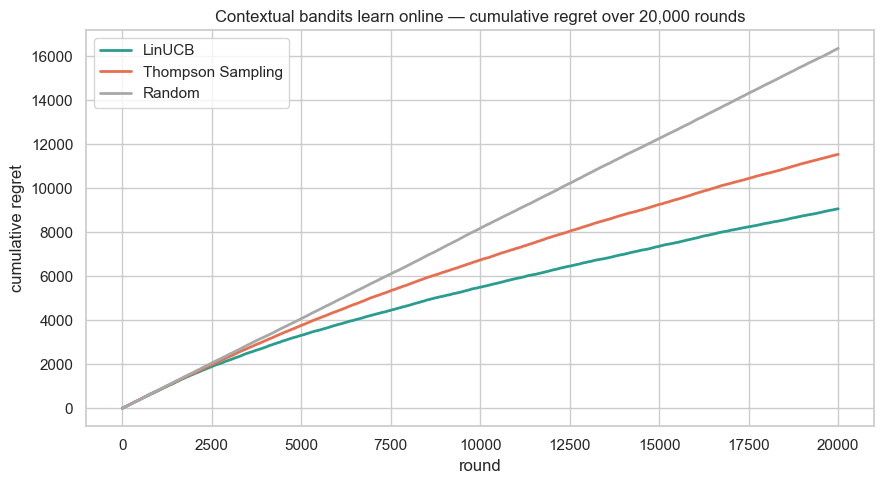

Both bandits beat random from round 1 and the gap widens as they learn:
  LinUCB final cumulative regret:            9061
  Thompson Sampling final cumulative regret:  11536
  Random final cumulative regret:             16349
  LinUCB avg regret first 20% -> last 20%:     0.693 -> 0.334


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"LinUCB": "#2a9d8f", "Thompson Sampling": "#e76f51", "Random": "#a8a8a8"}
for name, res in results.items():
    ax.plot(res["cumulative_regret"], label=name, color=colors[name], linewidth=2)
ax.set_xlabel("round"); ax.set_ylabel("cumulative regret")
ax.set_title(f"Contextual bandits learn online — cumulative regret over {N_ROUNDS:,} rounds")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "05_bandit_regret.png", dpi=120, bbox_inches="tight")
plt.show()

print("Both bandits beat random from round 1 and the gap widens as they learn:")
print(f"  LinUCB final cumulative regret:            {results['LinUCB']['cumulative_regret'][-1]:.0f}")
print(f"  Thompson Sampling final cumulative regret:  {results['Thompson Sampling']['cumulative_regret'][-1]:.0f}")
print(f"  Random final cumulative regret:             {results['Random']['cumulative_regret'][-1]:.0f}")
print(f"  LinUCB avg regret first 20% -> last 20%:     {summary.loc['LinUCB','avg_regret_first_20pct']:.3f} -> {summary.loc['LinUCB','avg_regret_last_20pct']:.3f}")

## 3. Switch-DR: evaluating the bandit's learned policy from logs

The bandit above learned *online*, with direct access to the reward every
round. In production, you don't get to A/B test every candidate policy —
you'd evaluate the policy the bandit converged to using the same off-policy
tools from notebooks 03-04, applied to logs collected under whatever policy
was live at the time.

We convert LinUCB's final per-arm point estimates into a stochastic policy
(softmax over `theta_a . x`), simulate logs under a popularity logging
policy, and compare IPS / Doubly Robust / **Switch-DR** against the true
value of the learned policy — the same validation notebook 04 ran for the
iALS/popularity candidates, now for a policy that came out of online
learning instead of a batch fit.

In [5]:
from sklearn.linear_model import LogisticRegression
from src.ope.estimators import (softmax_policy, simulate_bandit_logs, true_policy_value,
                                 doubly_robust, switch_dr, direct_method, ips)

learned_theta = linucb.theta()                      # (N_CAND, CONTEXT_FACTORS)
learned_scores = user_context @ learned_theta.T      # (n_users, N_CAND)
pi_learned = softmax_policy(learned_scores, temperature=0.5, epsilon=0.05)

pop_scores = np.tile(pop[cand], (len(users), 1))
pi0 = softmax_policy(pop_scores, temperature=pop[cand].std() * 3, epsilon=0.5)   # logging policy

log = simulate_bandit_logs(pi0, R, seed=0)
u, a, r, ps = log["context"], log["action"], log["reward"], log["pscore"]

rm = LogisticRegression(max_iter=500).fit(
    np.column_stack([learned_scores[u, a], np.log1p(pop[cand][a])]), r)
feats_all = np.column_stack([learned_scores[u].ravel(), np.log1p(np.tile(pop[cand], len(u)))])
q_all = rm.predict_proba(feats_all)[:, 1].reshape(len(u), N_CAND)
q_logged = q_all[np.arange(len(u)), a]

tps = pi_learned[u, a]
v_target = np.sum(pi_learned[u] * q_all, axis=1)

truth = true_policy_value(pi_learned, R)
estimates = pd.Series({
    "true_value (unknowable in practice)": truth,
    "IPS":       ips(r, ps, tps),
    "DM":        direct_method(v_target),
    "DR":        doubly_robust(r, ps, tps, q_logged, v_target),
    "Switch-DR (tau=5)": switch_dr(r, ps, tps, q_logged, v_target, tau=5.0),
})
estimates.to_frame("value")

,value
true_value (unknowable in practice),0.231745
IPS,0.236895
DM,0.242981
DR,0.234520
Switch-DR (tau=5),0.234520


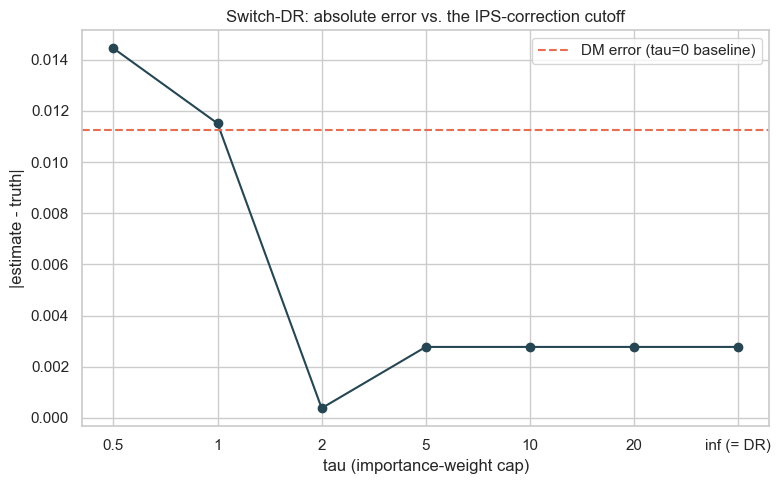

lowest-error tau on this run: 2
Switch-DR interpolates between DM (tau=0, high bias/low variance) and
DR (tau=inf, unbiased but variance-fragile) — the right tau is a bias/
variance trade-off decision, not a free lunch.


In [6]:
taus = [0.5, 1, 2, 5, 10, 20, np.inf]
switch_estimates, switch_bias = [], []
for tau in taus:
    est = switch_dr(r, ps, tps, q_logged, v_target, tau=tau)
    switch_estimates.append(est)
    switch_bias.append(abs(est - truth))

tau_labels = [str(t) if np.isfinite(t) else "inf (= DR)" for t in taus]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau_labels, switch_bias, marker="o", color="#264653")
ax.axhline(abs(direct_method(v_target) - truth), linestyle="--", color="#e76f51",
           label="DM error (tau=0 baseline)")
ax.set_xlabel("tau (importance-weight cap)"); ax.set_ylabel("|estimate - truth|")
ax.set_title("Switch-DR: absolute error vs. the IPS-correction cutoff")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "05_switch_dr_tau.png", dpi=120, bbox_inches="tight")
plt.show()

best_tau = taus[int(np.argmin(switch_bias))]
print(f"lowest-error tau on this run: {best_tau}")
print("Switch-DR interpolates between DM (tau=0, high bias/low variance) and")
print("DR (tau=inf, unbiased but variance-fragile) — the right tau is a bias/")
print("variance trade-off decision, not a free lunch.")

## Takeaways

1. **Both contextual bandits learn online and beat random exploration** —
   LinUCB's average regret drops as it accumulates interactions, and its
   cumulative regret ends far below the random-arm floor.
2. **A compact context (8 factors) was a deliberate choice**, not the
   64-factor embedding used for the offline recommender — sample efficiency
   under a limited online budget (200 arms, 20k rounds) matters more here
   than representational capacity.
3. **Switch-DR is a genuine bias/variance dial, not a strictly-better
   estimator** — the right tau depends on how heavy-tailed the importance
   weights are for the specific target/logging policy pair, which is exactly
   why the estimator ships with a tau sweep rather than a fixed default.